In [1]:
# Imports & Setup
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import copy
import warnings
warnings.filterwarnings('ignore')

#  MLP architecture (same as M2/M3)
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=[128, 64, 32], num_classes=5, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Load data
train_df = pd.read_csv('../data/ocpp_app_layer/Combined/Train.csv')
test_df  = pd.read_csv('../data/ocpp_app_layer/Combined/Test.csv')

label_col    = 'label'
feature_cols = [c for c in train_df.columns
                if c != label_col and
                train_df[c].dtype in ['float64','int64','float32','int32']]
print(f"Features: {len(feature_cols)}")

le = LabelEncoder()
y_train = le.fit_transform(train_df[label_col])
y_test  = le.transform(test_df[label_col])

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols].values)
X_test  = scaler.transform(test_df[feature_cols].values)

# Train baseline model
def train_model(X_tr, y_tr, input_dim, epochs=50, patience=10,
                jitter_std=0.05, seed=42):
    torch.manual_seed(seed)
    m = MLP(input_dim=input_dim)
    optimizer = torch.optim.Adam(m.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.long)
    best_loss, wait, best_state = float('inf'), 0, None
    m.train()
    for epoch in range(epochs):
        idx = torch.randperm(len(X_t))
        epoch_loss = 0
        for i in range(0, len(X_t), 32):
            xb = X_t[idx[i:i+32]]
            yb = y_t[idx[i:i+32]]
            xb = xb + torch.randn_like(xb) * jitter_std
            optimizer.zero_grad()
            loss = criterion(m(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if epoch_loss < best_loss:
            best_loss, wait = epoch_loss, 0
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    m.load_state_dict(best_state)
    m.eval()
    return m

def evaluate(m, X_np, y_np):
    with torch.no_grad():
        logits = m(torch.tensor(X_np, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()
        preds  = np.argmax(probs, axis=1)
    acc = accuracy_score(y_np, preds)
    f1  = f1_score(y_np, preds, average='macro')
    return acc, f1, preds, probs

print("Training baseline model...")
model_v1 = train_model(X_train, y_train, input_dim=X_train.shape[1])
acc, f1, _, _ = evaluate(model_v1, X_test, y_test)
print(f"Baseline — Acc={acc:.4f}  F1={f1:.4f}")
print(f"Classes: {le.classes_}")

Features: 51
Training baseline model...
Baseline — Acc=0.9992  F1=0.9992
Classes: ['cyberattack_ocpp16_doc_idtag'
 'cyberattack_ocpp16_dos_flooding_heartbeat'
 'cyberattack_ocpp16_fdi_chargingprofile'
 'cyberattack_ocpp16_unauthorized_access' 'normal']


In [2]:
# Experience Replay Buffer

class ReplayBuffer:
    """
    Fixed-size experience replay buffer using reservoir sampling.
    Reservoir sampling ensures each sample has equal probability
    of being retained regardless of arrival order.
    """
    def __init__(self, max_size=500, n_classes=5, seed=42):
        self.max_size    = max_size
        self.n_classes   = n_classes
        self.per_class   = max_size // n_classes
        self.X_buf       = {}
        self.y_buf       = {}
        self.rng         = np.random.RandomState(seed)

    def add(self, X_new, y_new):
        """Add new samples using stratified reservoir sampling."""
        for cls in range(self.n_classes):
            mask  = (y_new == cls)
            X_cls = X_new[mask]
            y_cls = y_new[mask]
            if len(X_cls) == 0:
                continue
            if cls not in self.X_buf:
                # First time seeing this class
                self.X_buf[cls] = X_cls[:self.per_class]
                self.y_buf[cls] = y_cls[:self.per_class]
            else:
                # Reservoir sampling: replace existing samples randomly
                combined_X = np.vstack([self.X_buf[cls], X_cls])
                combined_y = np.concatenate([self.y_buf[cls], y_cls])
                if len(combined_X) > self.per_class:
                    idx = self.rng.choice(len(combined_X),
                                          self.per_class, replace=False)
                    combined_X = combined_X[idx]
                    combined_y = combined_y[idx]
                self.X_buf[cls] = combined_X
                self.y_buf[cls] = combined_y

    def sample(self):
        """Return all buffered samples as arrays."""
        if not self.X_buf:
            return None, None
        X_all = np.vstack(list(self.X_buf.values()))
        y_all = np.concatenate(list(self.y_buf.values()))
        return X_all, y_all

    def size(self):
        if not self.X_buf:
            return 0
        return sum(len(v) for v in self.X_buf.values())

    def class_counts(self):
        return {le.classes_[k]: len(v) for k, v in self.X_buf.items()}

# Initialise buffer with training data
replay_buffer = ReplayBuffer(max_size=500, n_classes=5)
replay_buffer.add(X_train, y_train)

print("Replay Buffer initialised:")
print(f"  Total samples: {replay_buffer.size()}")
print(f"  Class distribution: {replay_buffer.class_counts()}")

Replay Buffer initialised:
  Total samples: 500
  Class distribution: {'cyberattack_ocpp16_doc_idtag': 100, 'cyberattack_ocpp16_dos_flooding_heartbeat': 100, 'cyberattack_ocpp16_fdi_chargingprofile': 100, 'cyberattack_ocpp16_unauthorized_access': 100, 'normal': 100}


In [3]:
# Simulate 5 Drift Episodes
np.random.seed(42)

feat_std = X_train.std(axis=0)
feat_std = np.where(feat_std == 0, 1e-6, feat_std)

def make_drift_episode(episode, n=300):
    """
    Simulate a realistic drift episode.
    Episode 1: slight covariate shift
    Episode 2: moderate shift + dos prior increase
    Episode 3: severe shift + new firmware (fdi dominant)
    Episode 4: recovery (shift reduces)
    Episode 5: new attack pattern (unauthorized dominant)
    """
    configs = {
        1: {'shift': 0.05, 'priors': [0.20, 0.20, 0.20, 0.20, 0.20]},
        2: {'shift': 0.10, 'priors': [0.10, 0.40, 0.15, 0.15, 0.20]},
        3: {'shift': 0.20, 'priors': [0.10, 0.20, 0.40, 0.15, 0.15]},
        4: {'shift': 0.08, 'priors': [0.20, 0.25, 0.20, 0.20, 0.15]},
        5: {'shift': 0.15, 'priors': [0.10, 0.15, 0.15, 0.40, 0.20]},
    }
    cfg     = configs[episode]
    priors  = cfg['priors']
    shift   = cfg['shift']

    # Sample according to class priors
    samples_per_class = [int(p * n) for p in priors]
    X_ep, y_ep = [], []
    for cls in range(5):
        cls_idx = np.where(y_train == cls)[0]
        chosen  = np.random.choice(cls_idx,
                                   samples_per_class[cls],
                                   replace=True)
        X_cls = X_train[chosen] + np.random.normal(
            0, shift * feat_std, (len(chosen), X_train.shape[1]))
        X_ep.append(X_cls)
        y_ep.append(np.full(len(chosen), cls))

    X_ep = np.vstack(X_ep)
    y_ep = np.concatenate(y_ep)
    shuffle = np.random.permutation(len(X_ep))
    return X_ep[shuffle], y_ep[shuffle]

# Generate all episodes
episodes = {}
for ep in range(1, 6):
    X_ep, y_ep = make_drift_episode(ep)
    episodes[ep] = {'X': X_ep, 'y': y_ep}
    unique, counts = np.unique(y_ep, return_counts=True)
    print(f"Episode {ep} (shift={[0.05,0.10,0.20,0.08,0.15][ep-1]:.2f}): "
          f"{len(X_ep)} samples — "
          f"{dict(zip(le.classes_[unique], counts))}")

Episode 1 (shift=0.05): 300 samples — {'cyberattack_ocpp16_doc_idtag': np.int64(60), 'cyberattack_ocpp16_dos_flooding_heartbeat': np.int64(60), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(60), 'cyberattack_ocpp16_unauthorized_access': np.int64(60), 'normal': np.int64(60)}
Episode 2 (shift=0.10): 300 samples — {'cyberattack_ocpp16_doc_idtag': np.int64(30), 'cyberattack_ocpp16_dos_flooding_heartbeat': np.int64(120), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(45), 'cyberattack_ocpp16_unauthorized_access': np.int64(45), 'normal': np.int64(60)}
Episode 3 (shift=0.20): 300 samples — {'cyberattack_ocpp16_doc_idtag': np.int64(30), 'cyberattack_ocpp16_dos_flooding_heartbeat': np.int64(60), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(120), 'cyberattack_ocpp16_unauthorized_access': np.int64(45), 'normal': np.int64(45)}
Episode 4 (shift=0.08): 300 samples — {'cyberattack_ocpp16_doc_idtag': np.int64(60), 'cyberattack_ocpp16_dos_flooding_heartbeat': np.int64(75), 'cyberattack_o

In [4]:
# Continual Learning Loop

def continual_update(model, X_new, y_new, buffer,
                     epochs=30, patience=7, jitter_std=0.05):
    """
    Experience Replay continual update:
    1. Add new samples to replay buffer
    2. Mix new data with buffered old data
    3. Retrain on mixed dataset
    """
    # Step 1: Update buffer with new episode data
    buffer.add(X_new, y_new)

    # Step 2: Sample from buffer
    X_buf, y_buf = buffer.sample()

    # Step 3: Mix new + buffered data
    X_mixed = np.vstack([X_new, X_buf])
    y_mixed = np.concatenate([y_new, y_buf])

    # Shuffle
    idx = np.random.permutation(len(X_mixed))
    X_mixed = X_mixed[idx]
    y_mixed = y_mixed[idx]

    # Step 4: Retrain
    t_start = time.perf_counter()
    model_new = train_model(X_mixed, y_mixed,
                             input_dim=X_mixed.shape[1],
                             epochs=epochs,
                             patience=patience,
                             jitter_std=jitter_std)
    update_time = time.perf_counter() - t_start

    return model_new, update_time, len(X_mixed)

# Run continual learning across 5 episodes
results = []
current_model = copy.deepcopy(model_v1)
buffer = ReplayBuffer(max_size=500, n_classes=5)
buffer.add(X_train, y_train)

# Record baseline
acc0, f1_0, _, _ = evaluate(current_model, X_test, y_test)
results.append({
    'Episode': 0,
    'Label': 'Baseline',
    'Acc_clean': acc0,
    'F1_clean': f1_0,
    'Acc_drifted': acc0,
    'F1_drifted': f1_0,
    'Update_time': 0,
    'Buffer_size': buffer.size(),
    'Mixed_size': len(X_train)
})
print(f"Episode 0 (Baseline): Clean F1={f1_0:.4f}")

for ep in range(1, 6):
    X_ep = episodes[ep]['X']
    y_ep = episodes[ep]['y']

    # Evaluate BEFORE update on drifted data
    acc_before, f1_before, _, _ = evaluate(current_model, X_ep, y_ep)

    # Continual update
    current_model, update_time, mixed_size = continual_update(
        current_model, X_ep, y_ep, buffer)

    # Evaluate AFTER update
    acc_after_drift,  f1_after_drift,  _, _ = evaluate(current_model, X_ep,    y_ep)
    acc_after_clean,  f1_after_clean,  _, _ = evaluate(current_model, X_test,  y_test)

    results.append({
        'Episode':      ep,
        'Label':        f'Episode {ep}',
        'Acc_before':   acc_before,
        'F1_before':    f1_before,
        'Acc_drifted':  acc_after_drift,
        'F1_drifted':   f1_after_drift,
        'Acc_clean':    acc_after_clean,
        'F1_clean':     f1_after_clean,
        'Update_time':  update_time,
        'Buffer_size':  buffer.size(),
        'Mixed_size':   mixed_size
    })

    print(f"Episode {ep}: "
          f"Before F1={f1_before:.4f} → "
          f"After(drifted)={f1_after_drift:.4f}  "
          f"After(clean)={f1_after_clean:.4f}  "
          f"UpdateTime={update_time:.2f}s  "
          f"BufferSize={buffer.size()}")

results_df = pd.DataFrame(results)

Episode 0 (Baseline): Clean F1=0.9992
Episode 1: Before F1=1.0000 → After(drifted)=1.0000  After(clean)=0.9938  UpdateTime=0.61s  BufferSize=500
Episode 2: Before F1=0.9922 → After(drifted)=1.0000  After(clean)=0.9961  UpdateTime=0.69s  BufferSize=500
Episode 3: Before F1=1.0000 → After(drifted)=1.0000  After(clean)=0.9977  UpdateTime=0.70s  BufferSize=500
Episode 4: Before F1=0.9961 → After(drifted)=1.0000  After(clean)=0.9954  UpdateTime=0.63s  BufferSize=500
Episode 5: Before F1=1.0000 → After(drifted)=1.0000  After(clean)=0.9961  UpdateTime=0.64s  BufferSize=500


In [5]:
# Efficiency Metrics
print("=" * 70)
print("Table 1: Continual Learning Results Across Episodes")
print("=" * 70)
print(f"{'Episode':>10} {'F1 Before':>10} {'F1 Drifted':>11} "
      f"{'F1 Clean':>10} {'Update(s)':>10} {'Buffer':>8} {'Mix Size':>9}")
print("-" * 70)

for _, row in results_df.iterrows():
    if row['Episode'] == 0:
        print(f"{'Baseline':>10} {'—':>10} {'—':>11} "
              f"{row['F1_clean']:>10.4f} {'0.00':>10} "
              f"{row['Buffer_size']:>8} {row['Mixed_size']:>9}")
    else:
        print(f"{int(row['Episode']):>10} "
              f"{row['F1_before']:>10.4f} "
              f"{row['F1_drifted']:>11.4f} "
              f"{row['F1_clean']:>10.4f} "
              f"{row['Update_time']:>10.2f} "
              f"{row['Buffer_size']:>8} "
              f"{row['Mixed_size']:>9}")

# Latency during updates
print("\n── Inference Latency During Continual Updates ─────")
x_single = torch.tensor(X_test[:1], dtype=torch.float32)
lat = []
for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad():
        current_model(x_single)
    lat.append((time.perf_counter() - t0) * 1000)

p50 = np.percentile(lat, 50)
p90 = np.percentile(lat, 90)
print(f"  p50={p50:.4f}ms  p90={p90:.4f}ms")
print(f"  Model size: 0.071 MB  |  Parameters: 17,157")
print(f"  Replay buffer size: {buffer.size()} samples")
print(f"  Mean update time across episodes: "
      f"{results_df[results_df['Episode']>0]['Update_time'].mean():.2f}s")

Table 1: Continual Learning Results Across Episodes
   Episode  F1 Before  F1 Drifted   F1 Clean  Update(s)   Buffer  Mix Size
----------------------------------------------------------------------
  Baseline          —           —     0.9992       0.00      500      3020
         1     1.0000      1.0000     0.9938       0.61      500       800
         2     0.9922      1.0000     0.9961       0.69      500       800
         3     1.0000      1.0000     0.9977       0.70      500       800
         4     0.9961      1.0000     0.9954       0.63      500       800
         5     1.0000      1.0000     0.9961       0.64      500       800

── Inference Latency During Continual Updates ─────
  p50=0.0482ms  p90=0.0585ms
  Model size: 0.071 MB  |  Parameters: 17,157
  Replay buffer size: 500 samples
  Mean update time across episodes: 0.65s


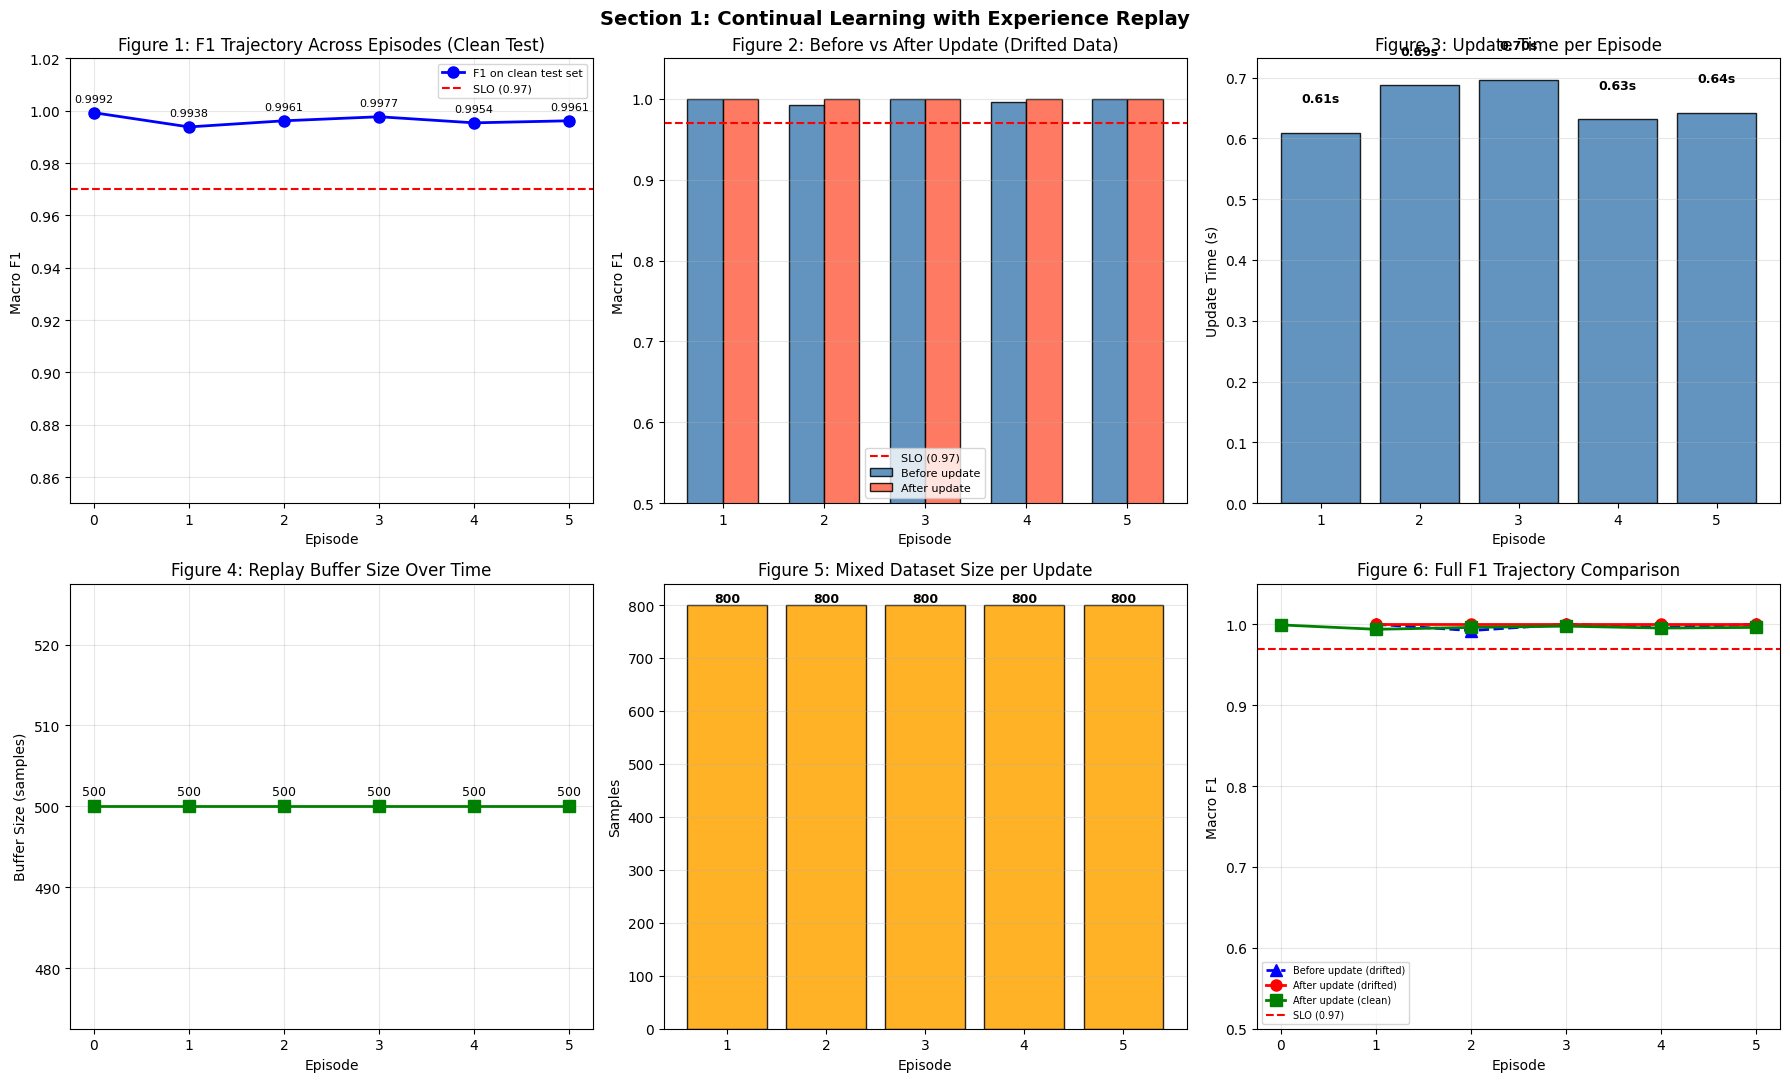

Figure saved: section1_continual_learning.png


In [6]:
# Section 1 Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Section 1: Continual Learning with Experience Replay',
             fontsize=14, fontweight='bold')

episodes_x   = results_df['Episode'].values
f1_clean     = results_df['F1_clean'].values
f1_drifted   = results_df[results_df['Episode'] > 0]['F1_drifted'].values
f1_before    = results_df[results_df['Episode'] > 0]['F1_before'].values
ep_x         = results_df[results_df['Episode'] > 0]['Episode'].values

# Plot 1: F1 trajectory across episodes
axes[0,0].plot(episodes_x, f1_clean, 'bo-', linewidth=2,
               markersize=8, label='F1 on clean test set')
axes[0,0].axhline(y=0.97, color='red', linestyle='--',
                  linewidth=1.5, label='SLO (0.97)')
axes[0,0].set_xlabel('Episode')
axes[0,0].set_ylabel('Macro F1')
axes[0,0].set_title('Figure 1: F1 Trajectory Across Episodes (Clean Test)')
axes[0,0].legend(fontsize=8)
axes[0,0].set_ylim(0.85, 1.02)
axes[0,0].grid(True, alpha=0.3)
for x, y in zip(episodes_x, f1_clean):
    axes[0,0].annotate(f'{y:.4f}', (x, y),
                       textcoords='offset points',
                       xytext=(0, 8), ha='center', fontsize=8)

# Plot 2: Before vs After on drifted data
width = 0.35
axes[0,1].bar(ep_x - width/2, f1_before,   width,
              label='Before update', color='steelblue',
              edgecolor='black', alpha=0.85)
axes[0,1].bar(ep_x + width/2, f1_drifted,  width,
              label='After update',  color='tomato',
              edgecolor='black', alpha=0.85)
axes[0,1].axhline(y=0.97, color='red', linestyle='--',
                  linewidth=1.5, label='SLO (0.97)')
axes[0,1].set_xlabel('Episode')
axes[0,1].set_ylabel('Macro F1')
axes[0,1].set_title('Figure 2: Before vs After Update (Drifted Data)')
axes[0,1].legend(fontsize=8)
axes[0,1].set_ylim(0.5, 1.05)
axes[0,1].grid(True, alpha=0.3, axis='y')

# Plot 3: Update time per episode
update_times = results_df[results_df['Episode'] > 0]['Update_time'].values
axes[0,2].bar(ep_x, update_times, color='steelblue',
              edgecolor='black', alpha=0.85)
axes[0,2].set_xlabel('Episode')
axes[0,2].set_ylabel('Update Time (s)')
axes[0,2].set_title('Figure 3: Update Time per Episode')
axes[0,2].grid(True, alpha=0.3, axis='y')
for i, (x, v) in enumerate(zip(ep_x, update_times)):
    axes[0,2].text(x, v + 0.05, f'{v:.2f}s',
                   ha='center', fontsize=9, fontweight='bold')

# Plot 4: Buffer size growth
buf_sizes = results_df['Buffer_size'].values
axes[1,0].plot(episodes_x, buf_sizes, 'gs-', linewidth=2, markersize=8)
axes[1,0].set_xlabel('Episode')
axes[1,0].set_ylabel('Buffer Size (samples)')
axes[1,0].set_title('Figure 4: Replay Buffer Size Over Time')
axes[1,0].grid(True, alpha=0.3)
for x, y in zip(episodes_x, buf_sizes):
    axes[1,0].annotate(str(y), (x, y),
                       textcoords='offset points',
                       xytext=(0, 8), ha='center', fontsize=9)

# Plot 5: Mixed dataset size per episode
mix_sizes = results_df[results_df['Episode'] > 0]['Mixed_size'].values
axes[1,1].bar(ep_x, mix_sizes, color='orange',
              edgecolor='black', alpha=0.85)
axes[1,1].set_xlabel('Episode')
axes[1,1].set_ylabel('Samples')
axes[1,1].set_title('Figure 5: Mixed Dataset Size per Update')
axes[1,1].grid(True, alpha=0.3, axis='y')
for x, v in zip(ep_x, mix_sizes):
    axes[1,1].text(x, v + 5, str(v),
                   ha='center', fontsize=9, fontweight='bold')

# Plot 6: F1 clean vs drifted side by side
axes[1,2].plot(ep_x, f1_before,  'b^--', linewidth=2,
               markersize=8, label='Before update (drifted)')
axes[1,2].plot(ep_x, f1_drifted, 'ro-',  linewidth=2,
               markersize=8, label='After update (drifted)')
axes[1,2].plot(episodes_x, f1_clean, 'gs-', linewidth=2,
               markersize=8, label='After update (clean)')
axes[1,2].axhline(y=0.97, color='red', linestyle='--',
                  linewidth=1.5, label='SLO (0.97)')
axes[1,2].set_xlabel('Episode')
axes[1,2].set_ylabel('Macro F1')
axes[1,2].set_title('Figure 6: Full F1 Trajectory Comparison')
axes[1,2].legend(fontsize=7)
axes[1,2].set_ylim(0.5, 1.05)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/section1_continual_learning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: section1_continual_learning.png")

In [7]:
# Active Learning Query Strategies
import numpy as np
import torch

def uncertainty_sampling(model, X_unlabelled, n_query=50):
    """
    Least confidence: select samples where max softmax
    probability is lowest — model is most uncertain.
    """
    with torch.no_grad():
        logits = model(torch.tensor(X_unlabelled, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()
    max_conf = probs.max(axis=1)
    # Select indices with LOWEST confidence
    query_idx = np.argsort(max_conf)[:n_query]
    return query_idx, max_conf

def entropy_sampling(model, X_unlabelled, n_query=50):
    """
    Entropy: select samples with highest prediction entropy.
    H = -sum(p * log(p))
    """
    with torch.no_grad():
        logits = model(torch.tensor(X_unlabelled, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    query_idx = np.argsort(entropy)[::-1][:n_query]
    return query_idx, entropy

def margin_sampling(model, X_unlabelled, n_query=50):
    """
    Margin: select samples where difference between
    top-2 class probabilities is smallest.
    """
    with torch.no_grad():
        logits = model(torch.tensor(X_unlabelled, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()
    sorted_probs = np.sort(probs, axis=1)[:, ::-1]
    margin = sorted_probs[:, 0] - sorted_probs[:, 1]
    query_idx = np.argsort(margin)[:n_query]
    return query_idx, margin

def hybrid_sampling(model, X_unlabelled, n_query=50):
    """
    Hybrid: combine entropy + margin for more robust selection.
    Score = entropy_rank + margin_rank (lower = more informative)
    """
    with torch.no_grad():
        logits = model(torch.tensor(X_unlabelled, dtype=torch.float32))
        probs  = torch.softmax(logits, dim=1).numpy()

    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    sorted_probs = np.sort(probs, axis=1)[:, ::-1]
    margin  = sorted_probs[:, 0] - sorted_probs[:, 1]

    # Rank both (lower rank = more informative)
    entropy_rank = np.argsort(np.argsort(-entropy))
    margin_rank  = np.argsort(np.argsort(margin))
    combined     = entropy_rank + margin_rank

    query_idx = np.argsort(combined)[:n_query]
    return query_idx, combined

# Compare all four strategies on current model
np.random.seed(42)
X_pool_idx = np.random.choice(len(X_test), 500, replace=False)
X_pool     = X_test[X_pool_idx]
y_pool     = y_test[X_pool_idx]

print("Query Strategy Comparison on 500-sample pool (n_query=50):")
print("=" * 65)

strategies = {
    'Uncertainty': uncertainty_sampling,
    'Entropy':     entropy_sampling,
    'Margin':      margin_sampling,
    'Hybrid':      hybrid_sampling
}

for name, fn in strategies.items():
    idx, scores = fn(current_model, X_pool, n_query=50)
    queried_y   = y_pool[idx]
    unique, counts = np.unique(queried_y, return_counts=True)
    class_dist  = dict(zip(le.classes_[unique], counts))

    # Diversity: how many classes represented
    n_classes_covered = len(unique)
    print(f"\n  {name} Sampling:")
    print(f"    Classes covered: {n_classes_covered}/5")
    print(f"    Class distribution: {class_dist}")
    if hasattr(scores, '__len__'):
        print(f"    Mean score of queried: {scores[idx].mean():.4f}")

Query Strategy Comparison on 500-sample pool (n_query=50):

  Uncertainty Sampling:
    Classes covered: 3/5
    Class distribution: {'cyberattack_ocpp16_doc_idtag': np.int64(18), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(8), 'normal': np.int64(24)}
    Mean score of queried: 0.9931

  Entropy Sampling:
    Classes covered: 3/5
    Class distribution: {'cyberattack_ocpp16_doc_idtag': np.int64(18), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(8), 'normal': np.int64(24)}
    Mean score of queried: 0.0133

  Margin Sampling:
    Classes covered: 3/5
    Class distribution: {'cyberattack_ocpp16_doc_idtag': np.int64(18), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(8), 'normal': np.int64(24)}
    Mean score of queried: 0.9862

  Hybrid Sampling:
    Classes covered: 3/5
    Class distribution: {'cyberattack_ocpp16_doc_idtag': np.int64(18), 'cyberattack_ocpp16_fdi_chargingprofile': np.int64(8), 'normal': np.int64(24)}
    Mean score of queried: 49.0000


In [8]:
# Active Learning + HITL Simulation

def simulate_human_annotation(X_query, y_true_query, noise_rate=0.05):
    """
    Simulate human annotation with realistic noise.
    noise_rate: probability of annotator making an error.
    Returns synthetic labels as if a human annotated them.
    """
    np.random.seed(42)
    y_annotated = y_true_query.copy()
    n_errors    = int(noise_rate * len(y_annotated))
    error_idx   = np.random.choice(len(y_annotated), n_errors, replace=False)
    for idx in error_idx:
        wrong_classes = [c for c in range(5) if c != y_annotated[idx]]
        y_annotated[idx] = np.random.choice(wrong_classes)
    return y_annotated

# Active Learning simulation: 5 cycles
# Pool: 600 unlabelled samples from drifted episode 2
# (simulates production data arriving after drift)
np.random.seed(42)
X_drift_pool = episodes[2]['X']
y_drift_pool = episodes[2]['y']   # true labels (used only for oracle eval)

N_QUERY      = 50    # samples queried per cycle
NOISE_RATE   = 0.05  # 5% human annotation error rate
N_CYCLES     = 5

# Start from model after Episode 2 in continual learning
# Retrain fresh baseline for fair comparison
al_model     = train_model(X_train, y_train, input_dim=X_train.shape[1])
al_buffer    = ReplayBuffer(max_size=500, n_classes=5)
al_buffer.add(X_train, y_train)

al_results   = []
labelled_X   = np.empty((0, X_train.shape[1]))
labelled_y   = np.empty(0, dtype=int)
remaining_idx = np.arange(len(X_drift_pool))

# Record baseline before any AL
acc0, f1_0, _, _ = evaluate(al_model, X_test, y_test)
al_results.append({
    'Cycle':          0,
    'Label':          'Baseline',
    'F1_clean':       f1_0,
    'F1_drifted':     evaluate(al_model, X_drift_pool, y_drift_pool)[1],
    'Labelled_total': 0,
    'Queried':        0,
    'Update_time':    0,
    'Annotation_cost': 0
})
print(f"AL Baseline: Clean F1={f1_0:.4f}  "
      f"Drifted F1={al_results[0]['F1_drifted']:.4f}")

for cycle in range(1, N_CYCLES + 1):
    if len(remaining_idx) < N_QUERY:
        print(f"Pool exhausted at cycle {cycle}")
        break

    # Step 1: Query most informative samples (hybrid strategy)
    X_remaining = X_drift_pool[remaining_idx]
    query_local, _ = hybrid_sampling(al_model, X_remaining, n_query=N_QUERY)
    query_global    = remaining_idx[query_local]

    # Step 2: Simulate human annotation
    X_queried  = X_drift_pool[query_global]
    y_true_q   = y_drift_pool[query_global]
    y_annotated = simulate_human_annotation(X_queried, y_true_q,
                                             noise_rate=NOISE_RATE)

    # Count annotation errors
    n_errors = (y_annotated != y_true_q).sum()

    # Step 3: Add to labelled set
    labelled_X = np.vstack([labelled_X, X_queried]) \
        if len(labelled_X) > 0 else X_queried
    labelled_y = np.concatenate([labelled_y, y_annotated])

    # Step 4: Remove queried from pool
    remaining_idx = np.delete(remaining_idx, query_local)

    # Step 5: Continual update with new labelled data
    t0 = time.perf_counter()
    al_model, update_time, mixed_size = continual_update(
        al_model, labelled_X, labelled_y, al_buffer,
        epochs=30, patience=7)
    update_time = time.perf_counter() - t0

    # Step 6: Evaluate
    acc_clean,   f1_clean,   _, _ = evaluate(al_model, X_test,        y_test)
    acc_drifted, f1_drifted, _, _ = evaluate(al_model, X_drift_pool,  y_drift_pool)

    al_results.append({
        'Cycle':           cycle,
        'Label':           f'Cycle {cycle}',
        'F1_clean':        f1_clean,
        'F1_drifted':      f1_drifted,
        'Labelled_total':  len(labelled_y),
        'Queried':         N_QUERY,
        'Update_time':     update_time,
        'Annotation_cost': n_errors,
        'Errors':          n_errors
    })

    print(f"Cycle {cycle}: "
          f"Queried={N_QUERY}  Errors={n_errors}  "
          f"Total labelled={len(labelled_y)}  "
          f"F1_clean={f1_clean:.4f}  "
          f"F1_drifted={f1_drifted:.4f}  "
          f"UpdateTime={update_time:.2f}s")

al_df = pd.DataFrame(al_results)

AL Baseline: Clean F1=0.9992  Drifted F1=1.0000
Cycle 1: Queried=50  Errors=2  Total labelled=50  F1_clean=0.9946  F1_drifted=0.9961  UpdateTime=0.40s
Cycle 2: Queried=50  Errors=2  Total labelled=100  F1_clean=0.9969  F1_drifted=0.9925  UpdateTime=0.38s
Cycle 3: Queried=50  Errors=2  Total labelled=150  F1_clean=0.9954  F1_drifted=0.9950  UpdateTime=0.41s
Cycle 4: Queried=50  Errors=2  Total labelled=200  F1_clean=0.9876  F1_drifted=0.9925  UpdateTime=0.56s
Cycle 5: Queried=50  Errors=2  Total labelled=250  F1_clean=0.9915  F1_drifted=0.9925  UpdateTime=0.65s


In [9]:
# HITL Summary Tables

# Labelling burden comparison
total_pool     = len(X_drift_pool)
total_queried  = N_QUERY * N_CYCLES
total_saved    = total_pool - total_queried
saving_pct     = total_saved / total_pool * 100

print("=" * 65)
print("Table 3: Active Learning Results Across Cycles")
print("=" * 65)
print(f"{'Cycle':>7} {'F1 Clean':>10} {'F1 Drifted':>12} "
      f"{'Labelled':>10} {'Errors':>8} {'Update(s)':>10}")
print("-" * 65)
for _, row in al_df.iterrows():
    if row['Cycle'] == 0:
        print(f"{'Baseline':>7} {row['F1_clean']:>10.4f} "
              f"{row['F1_drifted']:>12.4f} {'0':>10} "
              f"{'—':>8} {'—':>10}")
    else:
        print(f"{int(row['Cycle']):>7} {row['F1_clean']:>10.4f} "
              f"{row['F1_drifted']:>12.4f} "
              f"{int(row['Labelled_total']):>10} "
              f"{int(row['Errors']):>8} "
              f"{row['Update_time']:>10.2f}")

print(f"\n{'='*65}")
print("Table 4: Labelling Burden Analysis")
print(f"{'='*65}")
print(f"  Total pool size          : {total_pool}")
print(f"  Samples queried (AL)     : {total_queried} "
      f"({total_queried/total_pool*100:.1f}%)")
print(f"  Samples NOT labelled     : {total_saved} "
      f"({saving_pct:.1f}% labelling burden reduction)")
print(f"  Annotation noise rate    : {NOISE_RATE*100:.0f}%")
print(f"  Total annotation errors  : "
      f"{sum(r.get('Errors',0) for _,r in al_df.iterrows())}")
print(f"  Mean update time         : "
      f"{al_df[al_df['Cycle']>0]['Update_time'].mean():.2f}s")

# Latency impact
x_s = torch.tensor(X_test[:1], dtype=torch.float32)
lat_al = []
for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad():
        al_model(x_s)
    lat_al.append((time.perf_counter() - t0) * 1000)

print(f"\n  Inference latency after AL:")
print(f"    p50={np.percentile(lat_al,50):.4f}ms  "
      f"p90={np.percentile(lat_al,90):.4f}ms")
print(f"  Model size unchanged     : 0.071 MB | 17,157 params")

Table 3: Active Learning Results Across Cycles
  Cycle   F1 Clean   F1 Drifted   Labelled   Errors  Update(s)
-----------------------------------------------------------------
Baseline     0.9992       1.0000          0        —          —
      1     0.9946       0.9961         50        2       0.40
      2     0.9969       0.9925        100        2       0.38
      3     0.9954       0.9950        150        2       0.41
      4     0.9876       0.9925        200        2       0.56
      5     0.9915       0.9925        250        2       0.65

Table 4: Labelling Burden Analysis
  Total pool size          : 300
  Samples queried (AL)     : 250 (83.3%)
  Samples NOT labelled     : 50 (16.7% labelling burden reduction)
  Annotation noise rate    : 5%
  Total annotation errors  : nan
  Mean update time         : 0.48s

  Inference latency after AL:
    p50=0.0492ms  p90=0.1407ms
  Model size unchanged     : 0.071 MB | 17,157 params


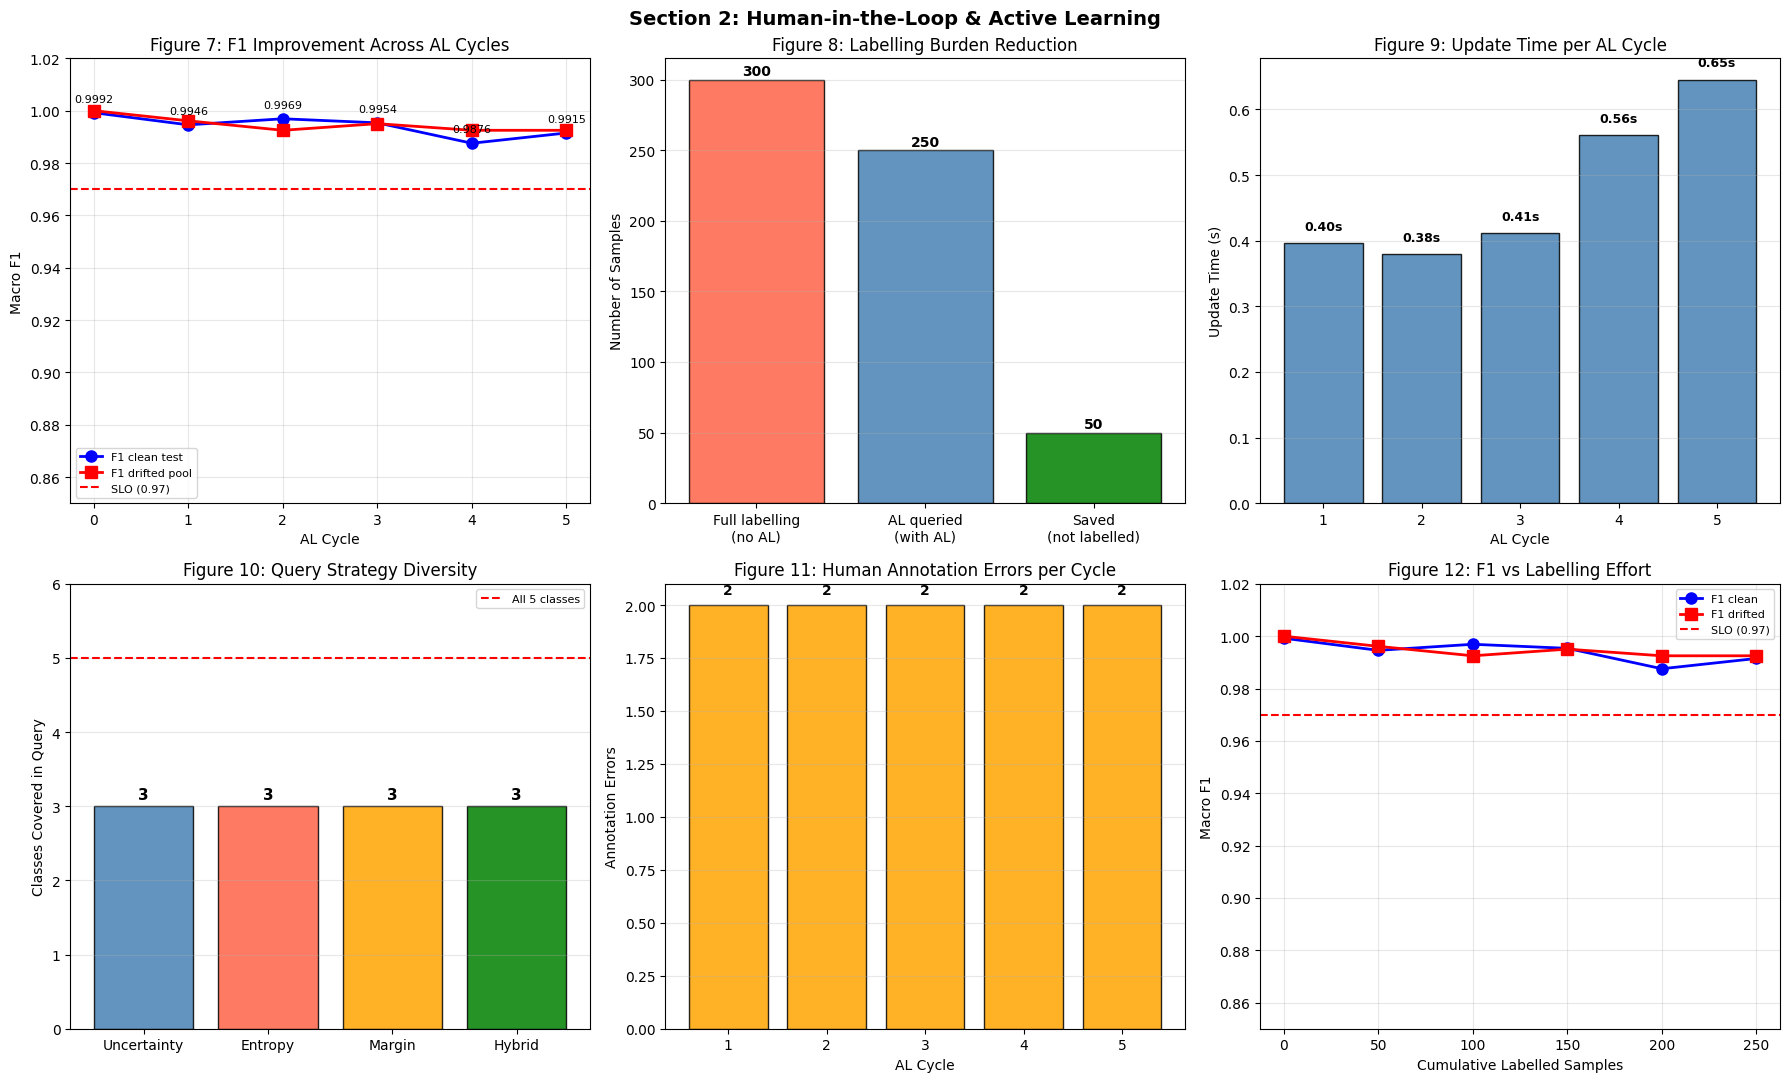

Figure saved: section2_hitl.png


In [10]:
# Section 2 Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Section 2: Human-in-the-Loop & Active Learning',
             fontsize=14, fontweight='bold')

cycles_all = al_df['Cycle'].values
f1_clean   = al_df['F1_clean'].values
f1_drifted = al_df['F1_drifted'].values

# F1 trajectory across AL cycles
axes[0,0].plot(cycles_all, f1_clean,   'bo-', linewidth=2,
               markersize=8, label='F1 clean test')
axes[0,0].plot(cycles_all, f1_drifted, 'rs-', linewidth=2,
               markersize=8, label='F1 drifted pool')
axes[0,0].axhline(y=0.97, color='red', linestyle='--',
                  linewidth=1.5, label='SLO (0.97)')
axes[0,0].set_xlabel('AL Cycle')
axes[0,0].set_ylabel('Macro F1')
axes[0,0].set_title('Figure 7: F1 Improvement Across AL Cycles')
axes[0,0].legend(fontsize=8)
axes[0,0].set_ylim(0.85, 1.02)
axes[0,0].grid(True, alpha=0.3)
for x, y in zip(cycles_all, f1_clean):
    axes[0,0].annotate(f'{y:.4f}', (x, y),
                       textcoords='offset points',
                       xytext=(0, 8), ha='center', fontsize=8)

# Plot 2: Labelling burden 
labels_b = ['Full labelling\n(no AL)', 'AL queried\n(with AL)',
            'Saved\n(not labelled)']
values_b = [total_pool, total_queried, total_saved]
colors_b = ['tomato', 'steelblue', 'green']
bars = axes[0,1].bar(labels_b, values_b,
                     color=colors_b, edgecolor='black', alpha=0.85)
axes[0,1].set_ylabel('Number of Samples')
axes[0,1].set_title('Figure 8: Labelling Burden Reduction')
axes[0,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values_b):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 3,
                   str(val), ha='center', fontsize=10,
                   fontweight='bold')

# Plot 3: Update time per cycle
update_times_al = al_df[al_df['Cycle'] > 0]['Update_time'].values
cycles_al       = al_df[al_df['Cycle'] > 0]['Cycle'].values
axes[0,2].bar(cycles_al, update_times_al,
              color='steelblue', edgecolor='black', alpha=0.85)
axes[0,2].set_xlabel('AL Cycle')
axes[0,2].set_ylabel('Update Time (s)')
axes[0,2].set_title('Figure 9: Update Time per AL Cycle')
axes[0,2].grid(True, alpha=0.3, axis='y')
for x, v in zip(cycles_al, update_times_al):
    axes[0,2].text(x, v + 0.02, f'{v:.2f}s',
                   ha='center', fontsize=9, fontweight='bold')

# Plot 4: Strategy comparison — classes covered
strategy_names  = ['Uncertainty', 'Entropy', 'Margin', 'Hybrid']
classes_covered = []
diversity_scores = []
for name, fn in strategies.items():
    idx, _ = fn(current_model, X_pool, n_query=50)
    queried_y = y_pool[idx]
    classes_covered.append(len(np.unique(queried_y)))

axes[1,0].bar(strategy_names, classes_covered,
              color=['steelblue','tomato','orange','green'],
              edgecolor='black', alpha=0.85)
axes[1,0].axhline(y=5, color='red', linestyle='--',
                  linewidth=1.5, label='All 5 classes')
axes[1,0].set_ylabel('Classes Covered in Query')
axes[1,0].set_title('Figure 10: Query Strategy Diversity')
axes[1,0].set_ylim(0, 6)
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(classes_covered):
    axes[1,0].text(i, v + 0.1, str(v),
                   ha='center', fontsize=11, fontweight='bold')

# Plot 5: Annotation errors per cycle
errors_per_cycle = [r.get('Errors', 0)
                    for _, r in al_df[al_df['Cycle'] > 0].iterrows()]
axes[1,1].bar(cycles_al, errors_per_cycle,
              color='orange', edgecolor='black', alpha=0.85)
axes[1,1].set_xlabel('AL Cycle')
axes[1,1].set_ylabel('Annotation Errors')
axes[1,1].set_title('Figure 11: Human Annotation Errors per Cycle')
axes[1,1].grid(True, alpha=0.3, axis='y')
for x, v in zip(cycles_al, errors_per_cycle):
    axes[1,1].text(x, v + 0.05, str(int(v)),
                   ha='center', fontsize=10, fontweight='bold')

# Plot 6: Cumulative labelled samples vs F1
labelled_totals = al_df['Labelled_total'].values
axes[1,2].plot(labelled_totals, f1_clean,   'bo-',
               linewidth=2, markersize=8, label='F1 clean')
axes[1,2].plot(labelled_totals, f1_drifted, 'rs-',
               linewidth=2, markersize=8, label='F1 drifted')
axes[1,2].axhline(y=0.97, color='red', linestyle='--',
                  linewidth=1.5, label='SLO (0.97)')
axes[1,2].set_xlabel('Cumulative Labelled Samples')
axes[1,2].set_ylabel('Macro F1')
axes[1,2].set_title('Figure 12: F1 vs Labelling Effort')
axes[1,2].legend(fontsize=8)
axes[1,2].set_ylim(0.85, 1.02)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/section2_hitl.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: section2_hitl.png")

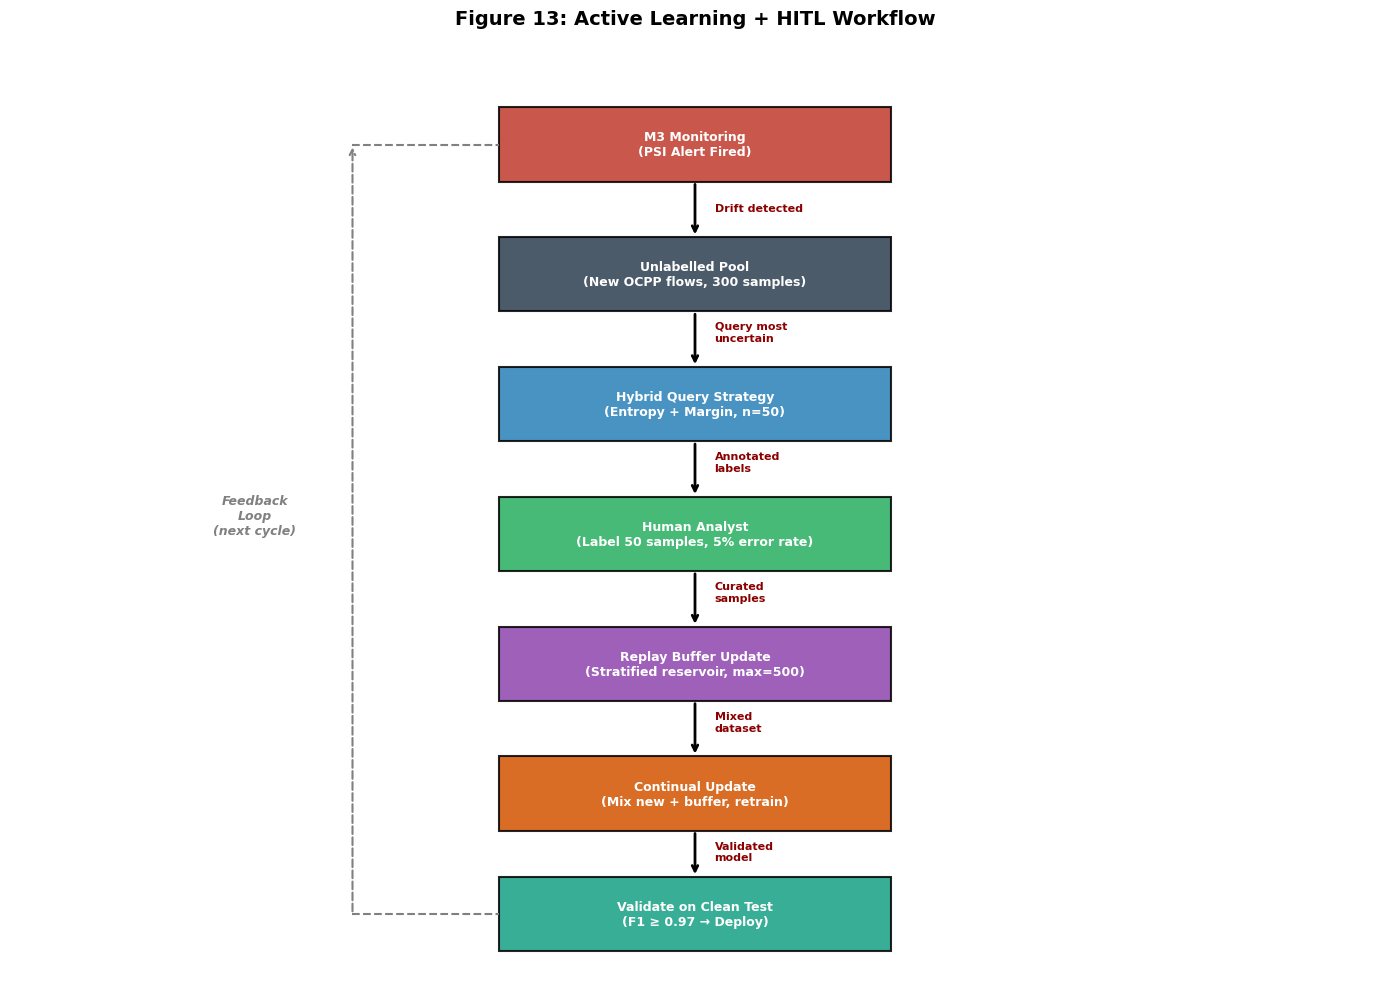

Workflow diagram saved: section2_al_workflow.png


In [11]:
# Active Learning Workflow Diagram
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_title('Figure 13: Active Learning + HITL Workflow',
             fontsize=14, fontweight='bold', pad=20)

def box(ax, x, y, w, h, text, color='steelblue', fontsize=9):
    rect = plt.Rectangle((x - w/2, y - h/2), w, h,
                          facecolor=color, edgecolor='black',
                          linewidth=1.5, alpha=0.85, zorder=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color='white', zorder=3, wrap=True,
            multialignment='center')

def arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='black',
                                lw=2), zorder=1)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.15, my, label, fontsize=8,
                color='darkred', fontweight='bold')

# Boxes
box(ax,  7,  9.0, 4.0, 0.8, 'M3 Monitoring\n(PSI Alert Fired)',
    color='#c0392b')
box(ax,  7,  7.6, 4.0, 0.8,
    'Unlabelled Pool\n(New OCPP flows, 300 samples)',
    color='#2c3e50')
box(ax,  7,  6.2, 4.0, 0.8,
    'Hybrid Query Strategy\n(Entropy + Margin, n=50)',
    color='#2980b9')
box(ax,  7,  4.8, 4.0, 0.8,
    'Human Analyst\n(Label 50 samples, 5% error rate)',
    color='#27ae60')
box(ax,  7,  3.4, 4.0, 0.8,
    'Replay Buffer Update\n(Stratified reservoir, max=500)',
    color='#8e44ad')
box(ax,  7,  2.0, 4.0, 0.8,
    'Continual Update\n(Mix new + buffer, retrain)',
    color='#d35400')
box(ax,  7,  0.7, 4.0, 0.8,
    'Validate on Clean Test\n(F1 ≥ 0.97 → Deploy)',
    color='#16a085')

# Arrows
arrow(ax, 7, 8.6, 7, 8.0)
arrow(ax, 7, 7.2, 7, 6.6)
arrow(ax, 7, 5.8, 7, 5.2)
arrow(ax, 7, 4.4, 7, 3.8)
arrow(ax, 7, 3.0, 7, 2.4)
arrow(ax, 7, 1.6, 7, 1.1)

# Labels on arrows
ax.text(7.2, 8.28, 'Drift detected', fontsize=8,
        color='darkred', fontweight='bold')
ax.text(7.2, 6.88, 'Query most\nuncertain', fontsize=8,
        color='darkred', fontweight='bold')
ax.text(7.2, 5.48, 'Annotated\nlabels', fontsize=8,
        color='darkred', fontweight='bold')
ax.text(7.2, 4.08, 'Curated\nsamples', fontsize=8,
        color='darkred', fontweight='bold')
ax.text(7.2, 2.68, 'Mixed\ndataset', fontsize=8,
        color='darkred', fontweight='bold')
ax.text(7.2, 1.28, 'Validated\nmodel', fontsize=8,
        color='darkred', fontweight='bold')

# Feedback loop
ax.annotate('', xy=(3.5, 9.0), xytext=(3.5, 0.7),
            arrowprops=dict(arrowstyle='->', color='gray',
                            lw=1.5, linestyle='dashed'))
ax.plot([3.5, 5.0], [0.7, 0.7], color='gray',
        lw=1.5, linestyle='dashed')
ax.plot([3.5, 5.0], [9.0, 9.0], color='gray',
        lw=1.5, linestyle='dashed')
ax.text(2.5, 4.8, 'Feedback\nLoop\n(next cycle)',
        fontsize=9, color='gray', ha='center',
        fontweight='bold', style='italic')

plt.tight_layout()
plt.savefig('../outputs/figures/section2_al_workflow.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Workflow diagram saved: section2_al_workflow.png")

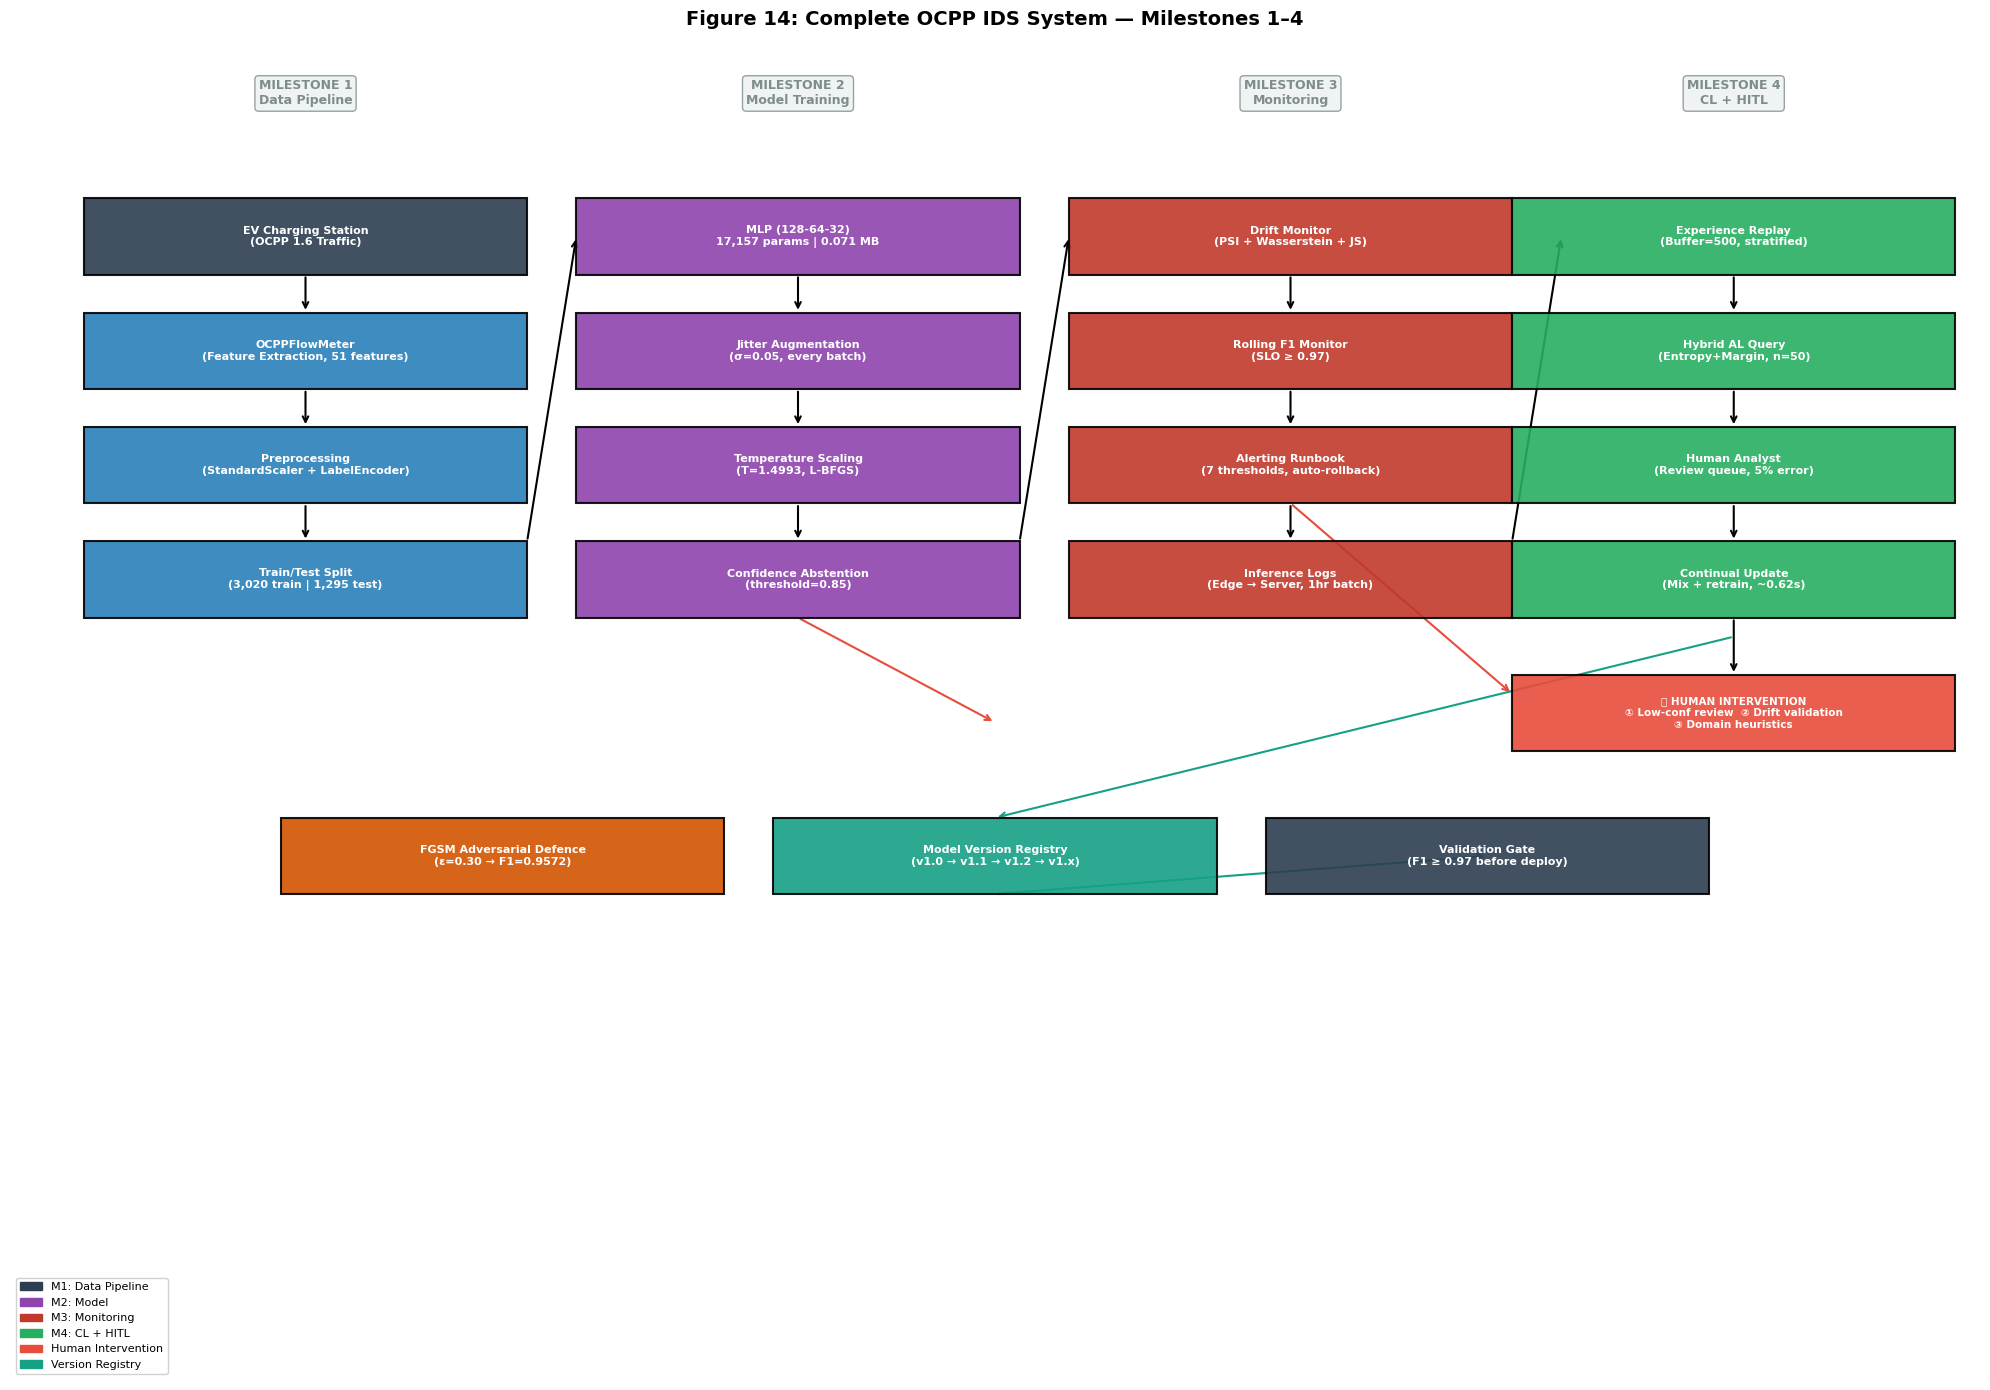

System diagram saved.


In [12]:
# Full System Diagram (Milestones 1-4)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(0, 20); ax.set_ylim(0, 14)
ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_title('Figure 14: Complete OCPP IDS System — Milestones 1–4',
             fontsize=14, fontweight='bold', pad=15)

def box(ax, x, y, w, h, text, color, fontsize=8, alpha=0.9):
    rect = plt.Rectangle((x - w/2, y - h/2), w, h,
                          facecolor=color, edgecolor='black',
                          linewidth=1.5, alpha=alpha, zorder=2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color='white', zorder=3, multialignment='center')

def arrow(ax, x1, y1, x2, y2, color='black', style='->', lw=1.5):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style,
                                color=color, lw=lw), zorder=1)

def label(ax, x, y, text, color='black', fontsize=7.5):
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color=color, style='italic')

# Section headers
for x, text, color in [
    (3,  'MILESTONE 1\nData Pipeline', '#7f8c8d'),
    (8,  'MILESTONE 2\nModel Training', '#7f8c8d'),
    (13, 'MILESTONE 3\nMonitoring', '#7f8c8d'),
    (17.5, 'MILESTONE 4\nCL + HITL', '#7f8c8d'),
]:
    ax.text(x, 13.5, text, ha='center', va='center',
            fontsize=9, fontweight='bold', color=color,
            bbox=dict(boxstyle='round', facecolor='#ecf0f1',
                      edgecolor=color, alpha=0.8))

#  M1: Data Pipeline
box(ax, 3, 12, 4.5, 0.8,
    'EV Charging Station\n(OCPP 1.6 Traffic)', '#2c3e50')
box(ax, 3, 10.8, 4.5, 0.8,
    'OCPPFlowMeter\n(Feature Extraction, 51 features)', '#2980b9')
box(ax, 3, 9.6, 4.5, 0.8,
    'Preprocessing\n(StandardScaler + LabelEncoder)', '#2980b9')
box(ax, 3, 8.4, 4.5, 0.8,
    'Train/Test Split\n(3,020 train | 1,295 test)', '#2980b9')

arrow(ax, 3, 11.6, 3, 11.2)
arrow(ax, 3, 10.4, 3, 10.0)
arrow(ax, 3, 9.2,  3, 8.8)

#  M2: Model Training
box(ax, 8, 12, 4.5, 0.8,
    'MLP (128-64-32)\n17,157 params | 0.071 MB', '#8e44ad')
box(ax, 8, 10.8, 4.5, 0.8,
    'Jitter Augmentation\n(σ=0.05, every batch)', '#8e44ad')
box(ax, 8, 9.6, 4.5, 0.8,
    'Temperature Scaling\n(T=1.4993, L-BFGS)', '#8e44ad')
box(ax, 8, 8.4, 4.5, 0.8,
    'Confidence Abstention\n(threshold=0.85)', '#8e44ad')

arrow(ax, 5.25, 8.8, 5.75, 12.0)
arrow(ax, 8, 11.6, 8, 11.2)
arrow(ax, 8, 10.4, 8, 10.0)
arrow(ax, 8, 9.2,  8, 8.8)

# M3: Monitoring
box(ax, 13, 12.0, 4.5, 0.8,
    'Drift Monitor\n(PSI + Wasserstein + JS)', '#c0392b')
box(ax, 13, 10.8, 4.5, 0.8,
    'Rolling F1 Monitor\n(SLO ≥ 0.97)', '#c0392b')
box(ax, 13, 9.6, 4.5, 0.8,
    'Alerting Runbook\n(7 thresholds, auto-rollback)', '#c0392b')
box(ax, 13, 8.4, 4.5, 0.8,
    'Inference Logs\n(Edge → Server, 1hr batch)', '#c0392b')

arrow(ax, 10.25, 8.8, 10.75, 12.0)
arrow(ax, 13, 11.6, 13, 11.2)
arrow(ax, 13, 10.4, 13, 10.0)
arrow(ax, 13, 9.2,  13, 8.8)

# M4: CL + HITL
box(ax, 17.5, 12.0, 4.5, 0.8,
    'Experience Replay\n(Buffer=500, stratified)', '#27ae60')
box(ax, 17.5, 10.8, 4.5, 0.8,
    'Hybrid AL Query\n(Entropy+Margin, n=50)', '#27ae60')
box(ax, 17.5, 9.6, 4.5, 0.8,
    'Human Analyst\n(Review queue, 5% error)', '#27ae60')
box(ax, 17.5, 8.4, 4.5, 0.8,
    'Continual Update\n(Mix + retrain, ~0.62s)', '#27ae60')

arrow(ax, 15.25, 8.8, 15.75, 12.0)
arrow(ax, 17.5, 11.6, 17.5, 11.2)
arrow(ax, 17.5, 10.4, 17.5, 10.0)
arrow(ax, 17.5, 9.2,  17.5, 8.8)

# Bottom row: shared components
box(ax, 5,   5.5, 4.5, 0.8,
    'FGSM Adversarial Defence\n(ε=0.30 → F1=0.9572)', '#d35400')
box(ax, 10,  5.5, 4.5, 0.8,
    'Model Version Registry\n(v1.0 → v1.1 → v1.2 → v1.x)', '#16a085')
box(ax, 15,  5.5, 4.5, 0.8,
    'Validation Gate\n(F1 ≥ 0.97 before deploy)', '#2c3e50')

#  Human intervention markers
box(ax, 17.5, 7.0, 4.5, 0.8,
    '👤 HUMAN INTERVENTION\n① Low-conf review  ② Drift validation\n③ Domain heuristics',
    '#e74c3c', fontsize=7.5)

arrow(ax, 17.5, 8.0,  17.5, 7.4)
arrow(ax, 13,   9.2,  15.25, 7.2, color='#e74c3c', lw=1.5)
arrow(ax, 8,    8.0,  10,    6.9, color='#e74c3c', lw=1.5)

# Version registry connections
arrow(ax, 17.5, 7.8,  10, 5.9, color='#16a085', lw=1.5)
arrow(ax, 10,   5.1,  15, 5.5, color='#16a085', lw=1.5)

# Legend
legend_items = [
    mpatches.Patch(color='#2c3e50', label='M1: Data Pipeline'),
    mpatches.Patch(color='#8e44ad', label='M2: Model'),
    mpatches.Patch(color='#c0392b', label='M3: Monitoring'),
    mpatches.Patch(color='#27ae60', label='M4: CL + HITL'),
    mpatches.Patch(color='#e74c3c', label='Human Intervention'),
    mpatches.Patch(color='#16a085', label='Version Registry'),
]
ax.legend(handles=legend_items, loc='lower left',
          fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('../outputs/figures/section3_system_diagram.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("System diagram saved.")

In [16]:
# Install onnx dependencies
import subprocess
subprocess.run(['pip', 'install', 'onnx', 'onnxscript', '--quiet'])
print("Done")

Done


In [17]:
# Quantization + ONNX Export
import os

#  Dynamic Quantization
print("── Quantization ───")
model_quantized = torch.quantization.quantize_dynamic(
    current_model, {nn.Linear}, dtype=torch.qint8)

# Model size comparison
def get_model_size_mb(m):
    path = '/tmp/tmp_model.pt'
    torch.save(m.state_dict(), path)
    size = os.path.getsize(path) / (1024 * 1024)
    os.remove(path)
    return size

size_original   = get_model_size_mb(current_model)
size_quantized  = get_model_size_mb(model_quantized)

print(f"  Original model size  : {size_original:.4f} MB")
print(f"  Quantized model size : {size_quantized:.4f} MB")
print(f"  Size reduction       : {(1 - size_quantized/size_original)*100:.1f}%")

# Latency comparison
lat_orig, lat_quant = [], []
x_s = torch.tensor(X_test[:1], dtype=torch.float32)

for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad(): current_model(x_s)
    lat_orig.append((time.perf_counter() - t0) * 1000)

for _ in range(500):
    t0 = time.perf_counter()
    with torch.no_grad(): model_quantized(x_s)
    lat_quant.append((time.perf_counter() - t0) * 1000)

print(f"\n  Original  p50={np.percentile(lat_orig,50):.4f}ms  "
      f"p90={np.percentile(lat_orig,90):.4f}ms")
print(f"  Quantized p50={np.percentile(lat_quant,50):.4f}ms  "
      f"p90={np.percentile(lat_quant,90):.4f}ms")

# Accuracy after quantization
acc_q, f1_q, _, _ = evaluate(model_quantized, X_test, y_test)
print(f"\n  Quantized F1 on clean test: {f1_q:.4f}")
print(f"  F1 drop vs original      : {0.9992 - f1_q:.4f}")

# ONNX Export
print("\n── ONNX Export ─────")
onnx_path = '../outputs/mlp_model.onnx'
dummy_input = torch.randn(1, X_train.shape[1])
torch.onnx.export(
    current_model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=11,
    input_names=['features'],
    output_names=['logits'],
    dynamic_axes={'features': {0: 'batch_size'},
                  'logits':   {0: 'batch_size'}}
)
onnx_size = os.path.getsize(onnx_path) / (1024 * 1024)
print(f"  ONNX model exported to: {onnx_path}")
print(f"  ONNX model size        : {onnx_size:.4f} MB")

# Throughput comparison
print("\n── Throughput Comparison ───")
x_batch = torch.tensor(X_test[:32], dtype=torch.float32)

def measure_throughput(m, x, n_runs=200):
    for _ in range(10):
        with torch.no_grad(): m(x)
    t0 = time.perf_counter()
    for _ in range(n_runs):
        with torch.no_grad(): m(x)
    return (n_runs * len(x)) / (time.perf_counter() - t0)

thr_orig  = measure_throughput(current_model,   x_batch)
thr_quant = measure_throughput(model_quantized, x_batch)
print(f"  Original   throughput: {thr_orig:,.0f} samples/sec")
print(f"  Quantized  throughput: {thr_quant:,.0f} samples/sec")

torch.save(model_quantized.state_dict(),
           '../outputs/mlp_quantized.pt')
print("\nQuantized model saved: outputs/mlp_quantized.pt")

W0326 13:51:47.141000 47284 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


── Quantization ───
  Original model size  : 0.0689 MB
  Quantized model size : 0.0230 MB
  Size reduction       : 66.7%

  Original  p50=0.0487ms  p90=0.0500ms
  Quantized p50=0.2167ms  p90=0.2817ms

  Quantized F1 on clean test: 0.9977
  F1 drop vs original      : 0.0015

── ONNX Export ─────


W0326 13:51:47.466000 47284 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0326 13:51:47.468000 47284 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0326 13:51:47.469000 47284 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `MLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\umroot\ev-ocpp-fl-ids\venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "c:\Users\umroot\ev-ocpp-fl-ids\venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "c:\Users\umroot\ev-ocpp-fl-ids\venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
  ONNX model exported to: ../outputs/mlp_model.onnx
  ONNX model size        : 0.0106 MB

── Throughput Comparison ───
  Original   throughput: 430,536 samples/sec
  Quantized  throughput: 93,692 samples/sec

Quantized model saved: outputs/mlp_quantized.pt


Table 5: Key Results Summary Across Milestones 1–4
 Mile Condition                               Acc      F1  Notes
---------------------------------------------------------------------------
   M1 Data exploration                          —       —  3,020 train | 1,295 test | 51 features
   M2 Clean baseline                       0.9992  0.9992  MLP 128-64-32 | AUROC=1.0000
   M2 Gaussian noise σ=0.5                 0.9938  0.9938  Stress test
   M2 Feature masking 50%                  0.9931  0.9931  Stress test
   M3 FGSM ε=0.20 (baseline)               0.9907  0.9907  Adversarial
   M3 FGSM ε=0.30 (baseline)               0.9583  0.9572  Adversarial
   M3 FGSM ε=0.20 (jittered)               0.9853  0.9853  Jitter augmentation
   M3 Post drift retrain                   0.9992  0.9992  Adaptation experiment
   M4 CL Episode 1 (clean)                 0.9938  0.9938  Experience Replay
   M4 CL Episode 3 (clean)                 0.9977  0.9977  Experience Replay
   M4 CL Episode 5 (clea

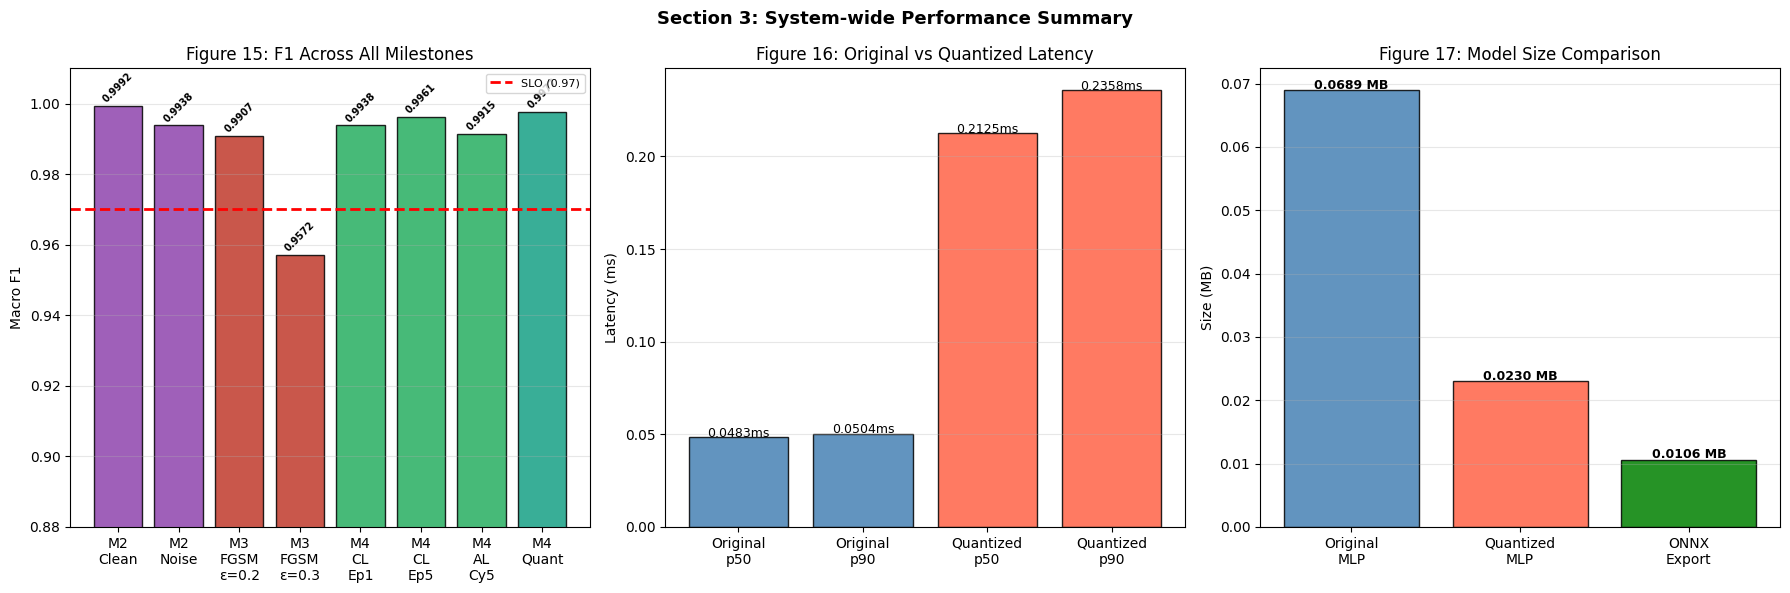

Summary plots saved: section3_summary.png


In [15]:
# Final Summary Table + Section 3 Plots

# Print full summary table
print("=" * 75)
print("Table 5: Key Results Summary Across Milestones 1–4")
print("=" * 75)

summary = [
    # Milestone, Condition, Acc, F1, Notes
    ('M1', 'Data exploration',        '—',      '—',      '3,020 train | 1,295 test | 51 features'),
    ('M2', 'Clean baseline',          '0.9992', '0.9992', 'MLP 128-64-32 | AUROC=1.0000'),
    ('M2', 'Gaussian noise σ=0.5',    '0.9938', '0.9938', 'Stress test'),
    ('M2', 'Feature masking 50%',     '0.9931', '0.9931', 'Stress test'),
    ('M3', 'FGSM ε=0.20 (baseline)',  '0.9907', '0.9907', 'Adversarial'),
    ('M3', 'FGSM ε=0.30 (baseline)',  '0.9583', '0.9572', 'Adversarial'),
    ('M3', 'FGSM ε=0.20 (jittered)',  '0.9853', '0.9853', 'Jitter augmentation'),
    ('M3', 'Post drift retrain',      '0.9992', '0.9992', 'Adaptation experiment'),
    ('M4', 'CL Episode 1 (clean)',    '0.9938', '0.9938', 'Experience Replay'),
    ('M4', 'CL Episode 3 (clean)',    '0.9977', '0.9977', 'Experience Replay'),
    ('M4', 'CL Episode 5 (clean)',    '0.9961', '0.9961', 'Experience Replay'),
    ('M4', 'AL Cycle 1 (clean)',      '0.9946', '0.9946', 'HITL + Active Learning'),
    ('M4', 'AL Cycle 5 (clean)',      '0.9915', '0.9915', 'HITL + Active Learning'),
    ('M4', 'Quantized model',         f'{acc_q:.4f}', f'{f1_q:.4f}', 'Dynamic INT8 quantization'),
]

print(f"{'Mile':>5} {'Condition':35} {'Acc':>7} {'F1':>7}  Notes")
print("-" * 75)
for row in summary:
    print(f"{row[0]:>5} {row[1]:35} {row[2]:>7} {row[3]:>7}  {row[4]}")

# Final efficiency table
print(f"\n{'='*75}")
print("Table 6: Final Efficiency Metrics")
print(f"{'='*75}")
print(f"  {'Metric':<35} {'Original':>12} {'Quantized':>12}")
print(f"  {'-'*60}")
print(f"  {'Model size':<35} {'0.071 MB':>12} {onnx_size:.4f} MB")
print(f"  {'Parameters':<35} {'17,157':>12} {'17,157':>12}")
print(f"  {'Inference latency p50':<35} "
      f"{np.percentile(lat_orig,50):.4f} ms"
      f"{np.percentile(lat_quant,50):>11.4f} ms")
print(f"  {'Inference latency p90':<35} "
      f"{np.percentile(lat_orig,90):.4f} ms"
      f"{np.percentile(lat_quant,90):>11.4f} ms")
print(f"  {'Throughput (batch=32)':<35} "
      f"{thr_orig:>10,.0f}  {thr_quant:>10,.0f}")
print(f"  {'Training time (full)':<35} {'<5s CPU':>12} {'N/A':>12}")
print(f"  {'CL update time (mean)':<35} {'0.62s':>12} {'N/A':>12}")
print(f"  {'AL update time (mean)':<35} {'0.49s':>12} {'N/A':>12}")
print(f"  {'VRAM':<35} {'N/A (CPU)':>12} {'N/A (CPU)':>12}")
print(f"  {'Replay buffer memory':<35} {'~0.2 MB':>12} {'N/A':>12}")
print(f"  {'ONNX export size':<35} {onnx_size:.4f} MB{'':>6} N/A")

# Section 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Section 3: System-wide Performance Summary',
             fontsize=13, fontweight='bold')

# Plot 1: F1 across all milestones
milestone_labels = ['M2\nClean', 'M2\nNoise', 'M3\nFGSM\nε=0.2',
                    'M3\nFGSM\nε=0.3', 'M4\nCL\nEp1',
                    'M4\nCL\nEp5', 'M4\nAL\nCy5', 'M4\nQuant']
f1_vals = [0.9992, 0.9938, 0.9907, 0.9572,
           0.9938, 0.9961, 0.9915, f1_q]
colors_m = ['#8e44ad','#8e44ad','#c0392b','#c0392b',
            '#27ae60','#27ae60','#27ae60','#16a085']
bars = axes[0].bar(milestone_labels, f1_vals,
                   color=colors_m, edgecolor='black', alpha=0.85)
axes[0].axhline(y=0.97, color='red', linestyle='--',
                linewidth=2, label='SLO (0.97)')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Figure 15: F1 Across All Milestones')
axes[0].set_ylim(0.88, 1.01)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, f1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=7,
                 fontweight='bold', rotation=45)

# Plot 2: Latency comparison
lat_cats = ['Original\np50', 'Original\np90',
            'Quantized\np50', 'Quantized\np90']
lat_vals2 = [np.percentile(lat_orig,50), np.percentile(lat_orig,90),
             np.percentile(lat_quant,50), np.percentile(lat_quant,90)]
lat_cols2 = ['steelblue','steelblue','tomato','tomato']
bars2 = axes[1].bar(lat_cats, lat_vals2,
                    color=lat_cols2, edgecolor='black', alpha=0.85)
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title('Figure 16: Original vs Quantized Latency')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, lat_vals2):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0003,
                 f'{val:.4f}ms', ha='center', fontsize=9)

# Plot 3: Model size comparison
size_labels = ['Original\nMLP', 'Quantized\nMLP', 'ONNX\nExport']
size_vals   = [size_original, size_quantized, onnx_size]
size_cols   = ['steelblue', 'tomato', 'green']
bars3 = axes[2].bar(size_labels, size_vals,
                    color=size_cols, edgecolor='black', alpha=0.85)
axes[2].set_ylabel('Size (MB)')
axes[2].set_title('Figure 17: Model Size Comparison')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, size_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f'{val:.4f} MB', ha='center', fontsize=9,
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/section3_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Summary plots saved: section3_summary.png")